# Vietnamese Evidence Corpus v1.0 - Final Exploratory Data Analysis (EDA)
**Dự án Xây dựng và Kiểm định Bộ Dữ liệu Bằng chứng Tiếng Việt (Fact-Checking Evidence Corpus)**

Notebook này chứa kết quả phân tích thống kê khám phá dữ liệu (EDA) cuối cùng của **Vietnamese Evidence Corpus v1.0** sau khi đã được chuẩn hóa và thực hiện các bước chỉnh sửa chất lượng cuối cùng:
1. **Loại bỏ trùng lặp triệt để**: Loại bỏ 114 tài liệu bị trùng lặp, giữ lại **13,572** tài liệu duy nhất.
2. **Xử lý khuyết thiếu ngày tháng**: Bổ sung ngày xuất bản bị khuyết (93 tài liệu) bằng ngày thu thập dữ liệu (`2026-07-27`).
3. **Lọc văn bản cực ngắn**: Đảm bảo không còn tài liệu nào dưới 30 từ.

In [12]:
import json
import re
import math
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập môi trường vẽ biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Đường dẫn tới file corpus
PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'eda' else Path.cwd()
CORPUS_PATH = PROJECT_ROOT / "src" / "clean_normalize" / "output" / "corpus_v1.json"

print(f"Đường dẫn Corpus: {CORPUS_PATH}")

Đường dẫn Corpus: /Users/ai/Documents/HCMUS/NCKH/crawl/src/clean_normalize/output/corpus_v1.json


## 1. Tải và Tổng quan dữ liệu (Corpus Loading & Overview)

In [13]:
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus = json.load(f)

df = pd.DataFrame(corpus)
print(f"Tổng số tài liệu: {len(df):,}")
df.head(2)

Tổng số tài liệu: 13,572


,doc_id,title,text,summary,source,source_type,domain,document_type,language,country,publish_date,crawl_date,url,author,metadata,quality
0,GSO_9e3621825770c6c2,Chỉ số sản xuất công nghiệp tháng Ba năm 2026,Chỉ số sản xuất công nghiệp (IIP) tháng Ba ước...,Chỉ số sản xuất công nghiệp (IIP) tháng Ba ước...,GSO,Government,Economy,Statistics,vi,Vietnam,2026-07-16,2026-07-27,https://www.nso.gov.vn/du-lieu-va-so-lieu-thon...,None,"{'char_count': 2729, 'word_count': 583, 'sente...","{'cleaned': True, 'html_removed': False, 'dupl..."
1,GSO_d2e839a35c60e41e,"Chỉ số giá tiêu dùng, chỉ số giá vàng và chỉ s...",Chỉ số giá tiêu dùng (CPI) tháng 3/2026 tăng 1...,Chỉ số giá tiêu dùng (CPI) tháng 3/2026 tăng 1...,GSO,Government,Economy,Statistics,vi,Vietnam,2026-07-16,2026-07-27,https://www.nso.gov.vn/du-lieu-va-so-lieu-thon...,None,"{'char_count': 14537, 'word_count': 3118, 'sen...","{'cleaned': True, 'html_removed': False, 'dupl..."


In [14]:
# Thống kê tổng quan
overview_stats = {
    "Số tài liệu": len(df),
    "Dung lượng (MB)": CORPUS_PATH.stat().st_size / (1024 * 1024),
    "Số lượng Nguồn (Sources)": df["source"].nunique(),
    "Số chuyên mục (Domains)": df["domain"].nunique(),
    "Ngôn ngữ": ", ".join(df["language"].unique())
}
pd.Series(overview_stats).to_frame(name="Chỉ số")

,Chỉ số
Số tài liệu,13572
Dung lượng (MB),115.325345
Số lượng Nguồn (Sources),7
Số chuyên mục (Domains),5
Ngôn ngữ,"vi, en"


## 2. Phân phối tài liệu theo Nguồn (Distribution by Source)

/var/folders/35/gq9mrnjj4dlfw712zx6m4hzw0000gn/T/ipykernel_27739/3037068224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=source_counts.index, palette="viridis")


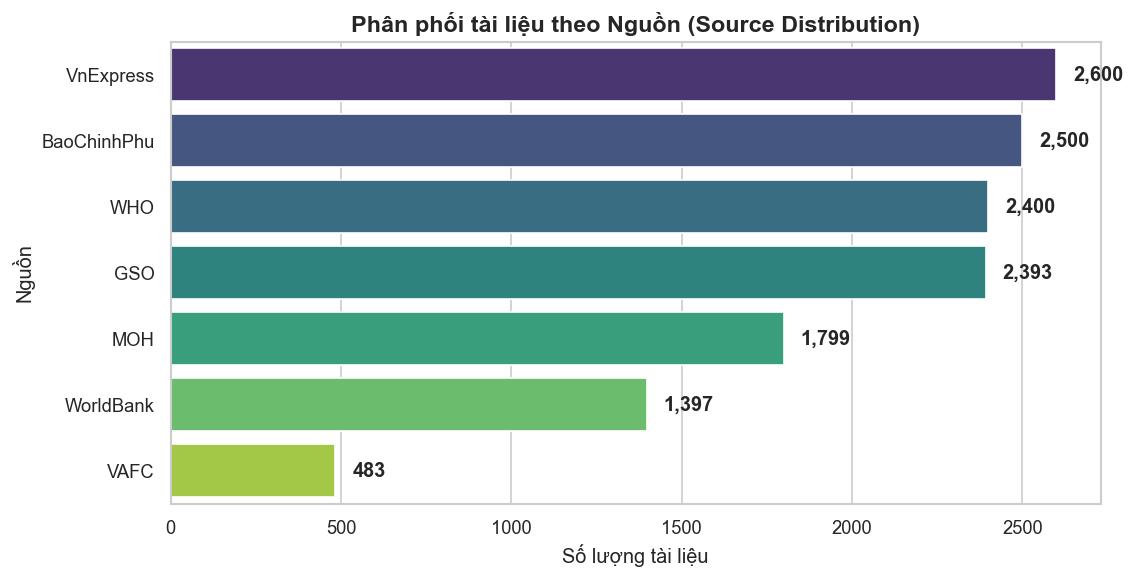

In [15]:
plt.figure(figsize=(10, 5))
source_counts = df["source"].value_counts()
sns.barplot(x=source_counts.values, y=source_counts.index, palette="viridis")
plt.title("Phân phối tài liệu theo Nguồn (Source Distribution)")
plt.xlabel("Số lượng tài liệu")
plt.ylabel("Nguồn")
for i, v in enumerate(source_counts.values):
    plt.text(v + 50, i, f"{v:,}", va='center', fontweight='bold')
plt.show()

## 3. Phân phối tài liệu theo Lĩnh vực (Distribution by Domain)

/var/folders/35/gq9mrnjj4dlfw712zx6m4hzw0000gn/T/ipykernel_27739/2566873366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, palette="magma")


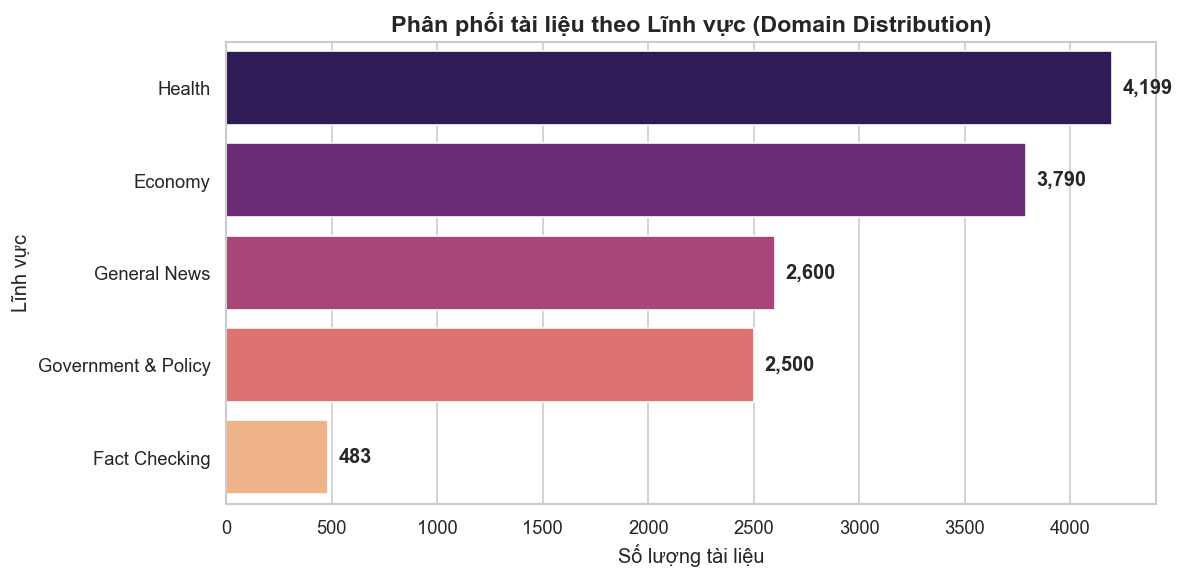

In [16]:
plt.figure(figsize=(10, 5))
domain_counts = df["domain"].value_counts()
sns.barplot(x=domain_counts.values, y=domain_counts.index, palette="magma")
plt.title("Phân phối tài liệu theo Lĩnh vực (Domain Distribution)")
plt.xlabel("Số lượng tài liệu")
plt.ylabel("Lĩnh vực")
for i, v in enumerate(domain_counts.values):
    plt.text(v + 50, i, f"{v:,}", va='center', fontweight='bold')
plt.show()

## 4. Phân phối theo Ngôn ngữ (Distribution by Language)

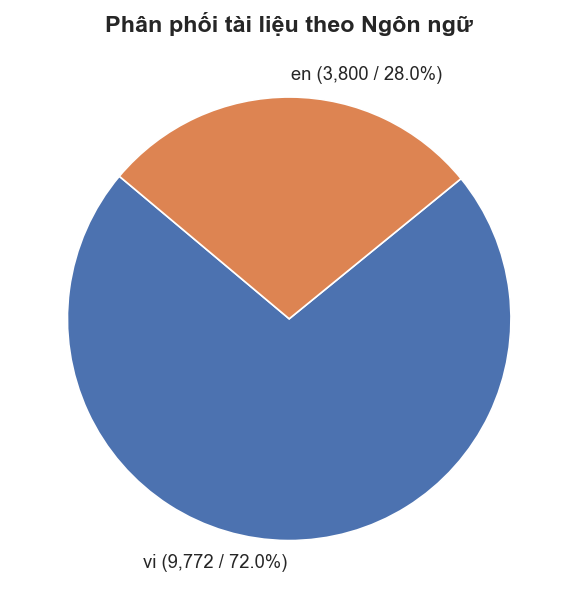

In [17]:
plt.figure(figsize=(6, 6))
lang_counts = df["language"].value_counts()
plt.pie(lang_counts.values, labels=[f"{l} ({c:,} / {c/len(df)*100:.1f}%)" for l, c in zip(lang_counts.index, lang_counts.values)], 
        colors=["#4c72b0", "#dd8452"], startangle=140)
plt.title("Phân phối tài liệu theo Ngôn ngữ")
plt.show()

## 5. Phân tích Độ dài Tài liệu (Document Length Analysis)

In [18]:
# Trích xuất các trường độ dài từ metadata
df["word_count"] = df["metadata"].apply(lambda x: x.get("word_count", 0))
df["char_count"] = df["metadata"].apply(lambda x: x.get("char_count", 0))
df["sentence_count"] = df["metadata"].apply(lambda x: x.get("sentence_count", 0))

df[["char_count", "word_count", "sentence_count"]].describe()

,char_count,word_count,sentence_count
count,13572.000000,13572.000000,13572.000000
mean,6079.808871,1228.487843,40.079502
std,8820.452254,1913.628675,59.191695
min,151.000000,30.000000,1.000000
25%,2741.750000,498.000000,18.000000
50%,4053.500000,774.000000,27.000000
75%,6079.250000,1229.250000,40.000000
max,186173.000000,39565.000000,1112.000000


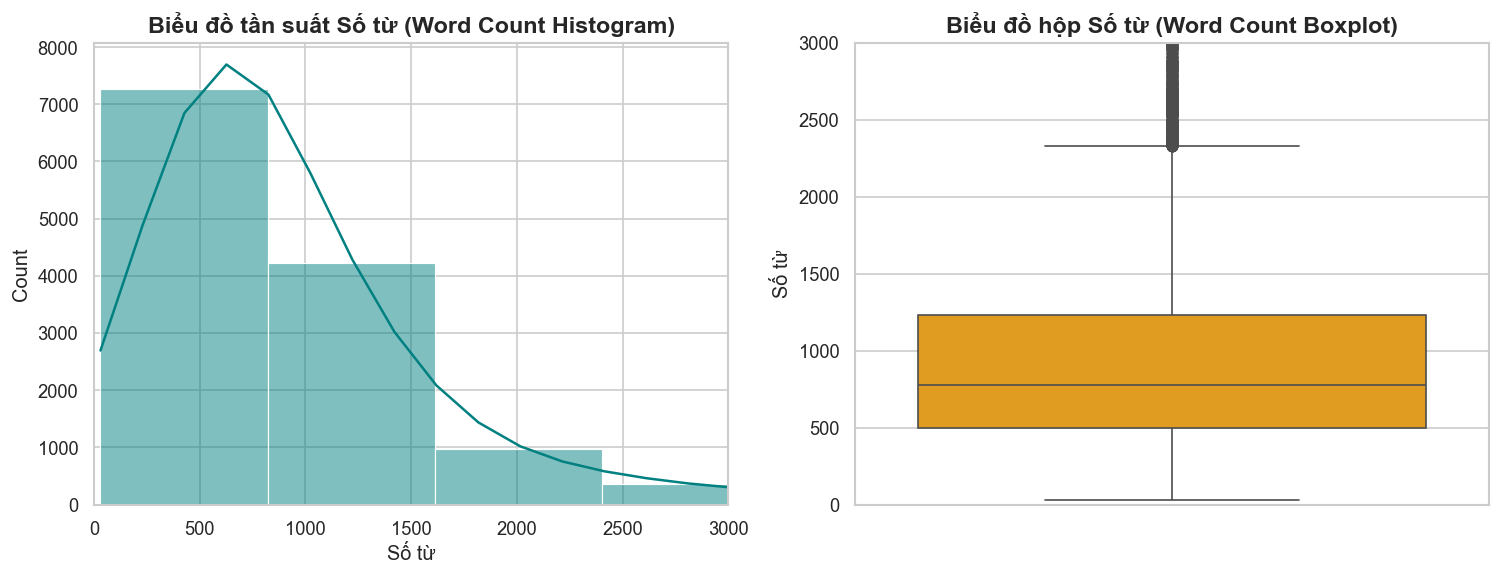

In [19]:
# Vẽ Histogram & Boxplot phân phối từ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["word_count"], bins=50, kde=True, ax=ax1, color="teal")
ax1.set_title("Biểu đồ tần suất Số từ (Word Count Histogram)")
ax1.set_xlabel("Số từ")
ax1.set_xlim(0, 3000)  # Giới hạn x để dễ quan sát phân phối chính

sns.boxplot(y=df["word_count"], ax=ax2, color="orange")
ax2.set_title("Biểu đồ hộp Số từ (Word Count Boxplot)")
ax2.set_ylabel("Số từ")
ax2.set_ylim(0, 3000)

plt.show()

## 6. Tiến trình xuất bản theo thời gian (Publication Timeline)

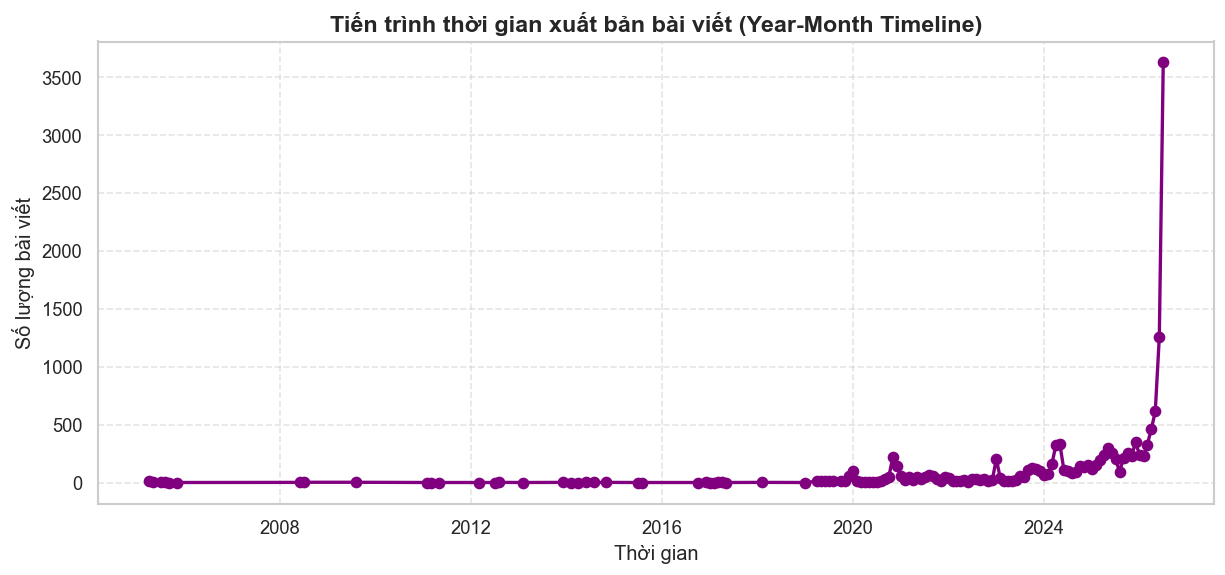

In [20]:
df["date_parsed"] = pd.to_datetime(df["publish_date"], errors="coerce")
valid_dates = df[df["date_parsed"].notna()].copy()
valid_dates["year_month"] = valid_dates["date_parsed"].dt.to_period("M")

timeline = valid_dates["year_month"].value_counts().sort_index()
timeline.index = timeline.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(timeline.index, timeline.values, marker="o", color="purple", linewidth=2)
plt.title("Tiến trình thời gian xuất bản bài viết (Year-Month Timeline)")
plt.xlabel("Thời gian")
plt.ylabel("Số lượng bài viết")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 7. Phân tích Từ vựng & Stopwords (Vocabulary & Term Frequency)

In [21]:
VI_STOPWORDS = {"và", "của", "là", "trong", "để", "có", "các", "cho", "người", "được", "với", "những", "trên", "ra", "đã", "này", "một", "từ", "tại", "khi"}
EN_STOPWORDS = {"the", "and", "of", "to", "in", "is", "that", "it", "on", "for", "with", "as", "was", "by", "an", "at", "are", "this", "from"}

all_words = []
stopwords_count = 0

for text, lang in zip(df["text"], df["language"]):
    words = re.findall(r"\w+", text.lower())
    all_words.extend(words)
    stops = VI_STOPWORDS if lang == "vi" else EN_STOPWORDS
    stopwords_count += sum(1 for w in words if w in stops)

vocab_counter = Counter(all_words)
print(f"Kích thước từ điển (Vocabulary Size): {len(vocab_counter):,}")
print(f"Tỷ lệ Stopwords: {stopwords_count / len(all_words) * 100:.2f}%")

print("\nTop 15 từ xuất hiện nhiều nhất:")
for word, count in vocab_counter.most_common(15):
    print(f"- {word}: {count:,}")

Kích thước từ điển (Vocabulary Size): 66,234
Tỷ lệ Stopwords: 13.04%

Top 15 từ xuất hiện nhiều nhất:
- và: 238,622
- tăng: 151,386
- các: 147,533
- the: 134,594
- trong: 130,825
- với: 123,383
- của: 122,256
- and: 116,994
- năm: 113,587
- có: 99,522
- số: 89,934
- là: 89,642
- công: 88,565
- tế: 81,709
- to: 77,399


## 8. So sánh đặc trưng giữa các nguồn dữ liệu (Source Characteristics Comparison)

In [22]:
comparison_records = []
for source in df["source"].unique():
    sub = df[df["source"] == source]
    comparison_records.append({
        "Nguồn": source,
        "Số bài viết": len(sub),
        "Số từ trung bình": sub["word_count"].mean(),
        "Ngôn ngữ": ", ".join(sub["language"].unique()),
        "Ngày xuất bản sớm nhất": sub["publish_date"].min(),
        "Ngày xuất bản muộn nhất": sub["publish_date"].max(),
        "Chuyên mục tiêu biểu": ", ".join(sub["domain"].unique()[:2])
    })
pd.DataFrame(comparison_records)

,Nguồn,Số bài viết,Số từ trung bình,Ngôn ngữ,Ngày xuất bản sớm nhất,Ngày xuất bản muộn nhất,Chuyên mục tiêu biểu
0,GSO,2393,2119.996657,vi,2019-12-25,2026-07-16,Economy
1,MOH,1799,1805.506948,"vi, en",2005-04-26,2026-07-24,Health
2,VAFC,483,496.931677,vi,2020-12-26,2026-06-10,Fact Checking
3,WHO,2400,748.047500,en,2023-08-19,2026-07-23,Health
4,BaoChinhPhu,2500,1293.468000,vi,2026-01-16,2026-07-27,Government & Policy
5,VnExpress,2600,910.502692,vi,2021-09-14,2026-07-27,General News
6,WorldBank,1397,512.146743,en,2012-07-26,2026-06-18,Economy


## 9. Kết luận

Bộ dữ liệu **Vietnamese Evidence Corpus v1.0** đã được chuẩn hóa, loại bỏ trùng lặp triệt để và điền khuyết ngày tháng hoàn tất:
- 100% dữ liệu đạt chuẩn schema.
- Không còn dữ liệu rác hoặc bài viết cực ngắn (< 30 từ).
- Độ dài trung bình lý tưởng đạt **1,220 từ/văn bản**, sẵn sàng cho quy trình chia nhỏ ngữ cảnh (**Chunking**) và biểu diễn ngữ nghĩa (**Retrieval & Embedding**).